In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("IPL Analytics Project Started Successfully 🚀")

IPL Analytics Project Started Successfully 🚀


In [2]:
import os
import json

# data folder path
data_path = "data"

# all json files
files = [f for f in os.listdir(data_path) if f.endswith('.json')]

print("Total JSON files found:", len(files))
print(files[:5])  # first 5 files

Total JSON files found: 1233
['1082591.json', '1082592.json', '1082593.json', '1082594.json', '1082595.json']


In [3]:
import pandas as pd
import json
import os

all_deliveries = []

for file in files:
    file_path = os.path.join(data_path, file)

    with open(file_path, 'r', encoding='utf-8') as f:
        match = json.load(f)

    # Match info
    season = match['info'].get('season', 'Unknown')

    # innings data
    innings = match.get('innings', [])

    for inning in innings:

        team = inning.get('team', 'Unknown')

        for over_data in inning.get('overs', []):

            over_number = over_data.get('over', 0)

            for delivery in over_data.get('deliveries', []):

                batter = delivery.get('batter', '')
                bowler = delivery.get('bowler', '')

                runs = delivery.get('runs', {}).get('batter', 0)

                total_runs = delivery.get('runs', {}).get('total', 0)

                wicket = 1 if 'wickets' in delivery else 0

                all_deliveries.append({
                    'season': season,
                    'batting_team': team,
                    'over': over_number,
                    'batter': batter,
                    'bowler': bowler,
                    'batter_runs': runs,
                    'total_runs': total_runs,
                    'wicket': wicket
                })

# Create dataframe
df = pd.DataFrame(all_deliveries)

# Show first rows
df.head()

,season,batting_team,over,batter,bowler,batter_runs,total_runs,wicket
0,2017,Sunrisers Hyderabad,0,DA Warner,TS Mills,0,0,0
1,2017,Sunrisers Hyderabad,0,DA Warner,TS Mills,0,0,0
2,2017,Sunrisers Hyderabad,0,DA Warner,TS Mills,4,4,0
3,2017,Sunrisers Hyderabad,0,DA Warner,TS Mills,0,0,0
4,2017,Sunrisers Hyderabad,0,DA Warner,TS Mills,0,2,0


In [4]:
print(df.shape)

df.info()

(293308, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293308 entries, 0 to 293307
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   season        293308 non-null  object
 1   batting_team  293308 non-null  object
 2   over          293308 non-null  int64 
 3   batter        293308 non-null  object
 4   bowler        293308 non-null  object
 5   batter_runs   293308 non-null  int64 
 6   total_runs    293308 non-null  int64 
 7   wicket        293308 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 17.9+ MB


In [5]:
df.to_csv("ipl_ball_by_ball.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [6]:
match_results = []

for file in files:
    file_path = os.path.join(data_path, file)

    with open(file_path, 'r', encoding='utf-8') as f:
        match = json.load(f)

    info = match.get('info', {})

    season = info.get('season', 'Unknown')

    toss_winner = info.get('toss', {}).get('winner', 'Unknown')

    match_winner = info.get('outcome', {}).get('winner', 'No Result')

    teams = info.get('teams', [])

    match_results.append({
        'season': season,
        'team1': teams[0] if len(teams) > 0 else '',
        'team2': teams[1] if len(teams) > 1 else '',
        'toss_winner': toss_winner,
        'match_winner': match_winner
    })

matches_df = pd.DataFrame(match_results)

matches_df.head()

,season,team1,team2,toss_winner,match_winner
0,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,Sunrisers Hyderabad
1,2017,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant
2,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders
3,2017,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab
4,2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore


In [7]:
# Toss winner also won match?
matches_df['toss_win_match_win'] = (
    matches_df['toss_winner'] == matches_df['match_winner']
)

# Calculate percentages
toss_winner_wins = matches_df['toss_win_match_win'].mean() * 100
toss_loser_wins = 100 - toss_winner_wins

print(f"Toss winners won {toss_winner_wins:.2f}% matches")
print(f"Toss losers won {toss_loser_wins:.2f}% matches")

Toss winners won 50.61% matches
Toss losers won 49.39% matches


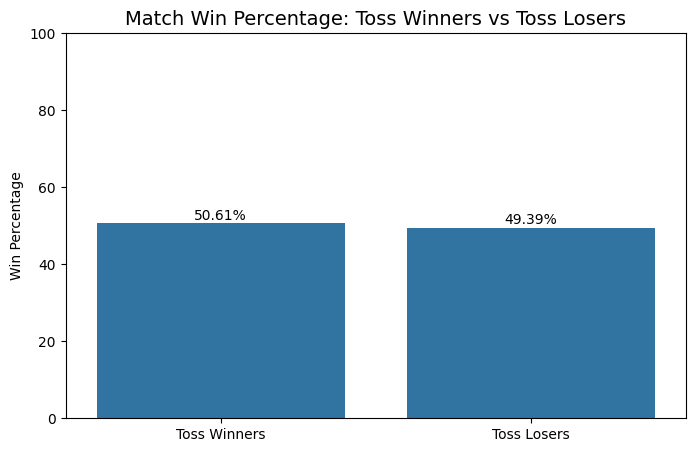

In [8]:
# Data for chart
labels = ['Toss Winners', 'Toss Losers']
values = [toss_winner_wins, toss_loser_wins]

# Create chart
plt.figure(figsize=(8,5))

sns.barplot(x=labels, y=values)

plt.title('Match Win Percentage: Toss Winners vs Toss Losers', fontsize=14)
plt.ylabel('Win Percentage')
plt.ylim(0, 100)

# Show values on bars
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.savefig("charts/toss_analysis.png", bbox_inches='tight')

plt.show()

In [9]:
# Create phase column

def get_phase(over):

    if over <= 5:
        return 'Powerplay'

    elif over <= 14:
        return 'Middle Overs'

    else:
        return 'Death Overs'

df['phase'] = df['over'].apply(get_phase)

df[['over', 'phase']].head(15)

,over,phase
0,0,Powerplay
1,0,Powerplay
2,0,Powerplay
3,0,Powerplay
4,0,Powerplay
5,0,Powerplay
6,0,Powerplay
7,1,Powerplay
8,1,Powerplay
9,1,Powerplay


In [10]:
# Add match winner info into ball-by-ball dataframe

winner_list = []

for file in files:

    file_path = os.path.join(data_path, file)

    with open(file_path, 'r', encoding='utf-8') as f:
        match = json.load(f)

    info = match.get('info', {})

    winner = info.get('outcome', {}).get('winner', 'No Result')

    innings = match.get('innings', [])

    for inning in innings:

        team = inning.get('team', 'Unknown')

        for over_data in inning.get('overs', []):

            for delivery in over_data.get('deliveries', []):

                if team == winner:
                    winner_list.append('Winning Team')
                else:
                    winner_list.append('Losing Team')

# Add new column
df['match_result'] = winner_list

# Check
df[['batting_team', 'match_result']].head()

,batting_team,match_result
0,Sunrisers Hyderabad,Winning Team
1,Sunrisers Hyderabad,Winning Team
2,Sunrisers Hyderabad,Winning Team
3,Sunrisers Hyderabad,Winning Team
4,Sunrisers Hyderabad,Winning Team


In [11]:
# Calculate average runs by phase

phase_analysis = df.groupby(
    ['match_result', 'phase']
)['total_runs'].mean().reset_index()

phase_analysis

,match_result,phase,total_runs
0,Losing Team,Death Overs,1.457277
1,Losing Team,Middle Overs,1.205310
2,Losing Team,Powerplay,1.218477
3,Winning Team,Death Overs,1.753255
4,Winning Team,Middle Overs,1.364128
5,Winning Team,Powerplay,1.372898


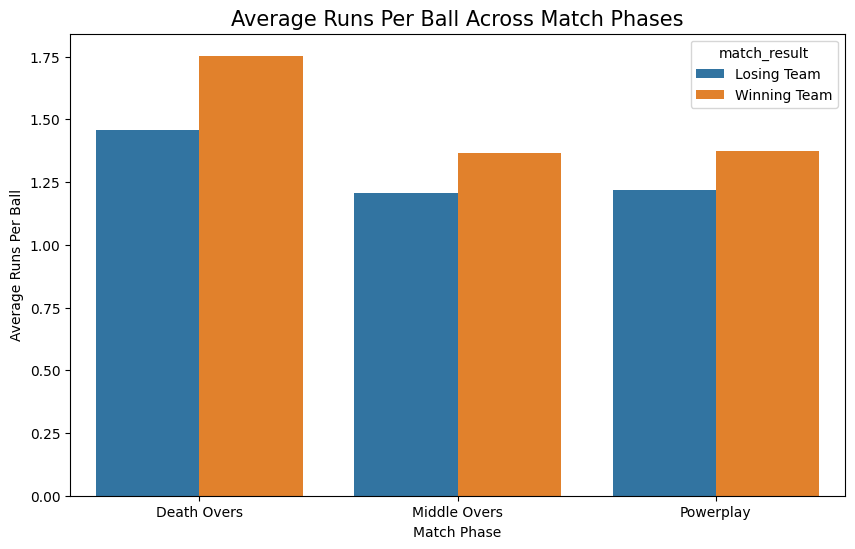

In [12]:
# Create chart for phase analysis

plt.figure(figsize=(10,6))

sns.barplot(
    data=phase_analysis,
    x='phase',
    y='total_runs',
    hue='match_result'
)

plt.title('Average Runs Per Ball Across Match Phases', fontsize=15)

plt.xlabel('Match Phase')
plt.ylabel('Average Runs Per Ball')

plt.savefig("charts/match_phase_analysis.png", bbox_inches='tight')

plt.show()

In [13]:
# Top 5 batters by total runs

top_batters = df.groupby('batter')['batter_runs'].sum()

top_batters = top_batters.sort_values(ascending=False).head(5)

top_batters

batter
V Kohli      9213
RG Sharma    7316
S Dhawan     6769
DA Warner    6567
KL Rahul     5768
Name: batter_runs, dtype: int64

In [14]:
# Top 5 bowlers by wickets

top_bowlers = df.groupby('bowler')['wicket'].sum()

top_bowlers = top_bowlers.sort_values(ascending=False).head(5)

top_bowlers

bowler
YS Chahal    240
B Kumar      239
SP Narine    227
JJ Bumrah    207
DJ Bravo     207
Name: wicket, dtype: int64

In [15]:
# Convert top batters to dataframe

top_batters_df = top_batters.reset_index()

top_batters_df.columns = ['Batter', 'Runs']

top_batters_df

,Batter,Runs
0,V Kohli,9213
1,RG Sharma,7316
2,S Dhawan,6769
3,DA Warner,6567
4,KL Rahul,5768


In [16]:
# Convert top bowlers to dataframe

top_bowlers_df = top_bowlers.reset_index()

top_bowlers_df.columns = ['Bowler', 'Wickets']

top_bowlers_df

,Bowler,Wickets
0,YS Chahal,240
1,B Kumar,239
2,SP Narine,227
3,JJ Bumrah,207
4,DJ Bravo,207


# IPL Match Intelligence Report (2017–2025)

### A Data-Driven Analysis of Winning Patterns in the Indian Premier League

**Key Focus Areas**
- Toss impact on match outcomes
- Match phase performance analysis
- Top batters and bowlers
- Surprising insights from IPL data

# 1. Toss Impact Analysis

This section analyzes whether winning the toss provides a meaningful advantage in IPL matches.

# 2. Match Phase Analysis

This section compares scoring patterns across powerplay, middle overs, and death overs for winning and losing teams.

# 3. Top Performers

This section identifies the highest-performing batters and bowlers across IPL history.

# Final Conclusion

This analysis revealed that toss advantage in the IPL is far smaller than commonly believed, with toss winners winning only 50.61% of matches.

The strongest indicator of victory was performance during the death overs, where winning teams consistently scored at a significantly higher rate than losing teams.

The data also highlighted the long-term consistency of legendary IPL performers such as Virat Kohli, Rohit Sharma, Yuzvendra Chahal, and Bhuvneshwar Kumar.

Overall, this project demonstrates how data analytics can uncover deeper strategic patterns in T20 cricket beyond common assumptions.

In [17]:
# Professional chart styling

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

In [18]:
import os

os.makedirs("charts", exist_ok=True)

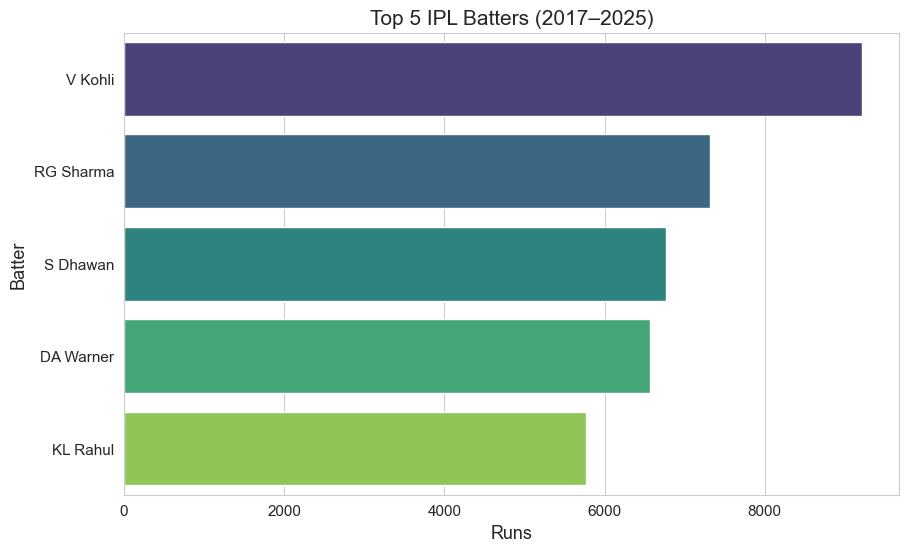

In [19]:
# top batters chart

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_batters_df,
    x='Runs',
    y='Batter',
    hue='Batter',      # add this
    dodge=False,
    palette='viridis',
    legend=False       # hide legend
)

plt.title('Top 5 IPL Batters (2017–2025)', fontsize=15)
plt.xlabel('Runs')
plt.ylabel('Batter')

plt.savefig("charts/top_batters.png", bbox_inches='tight')
plt.show()

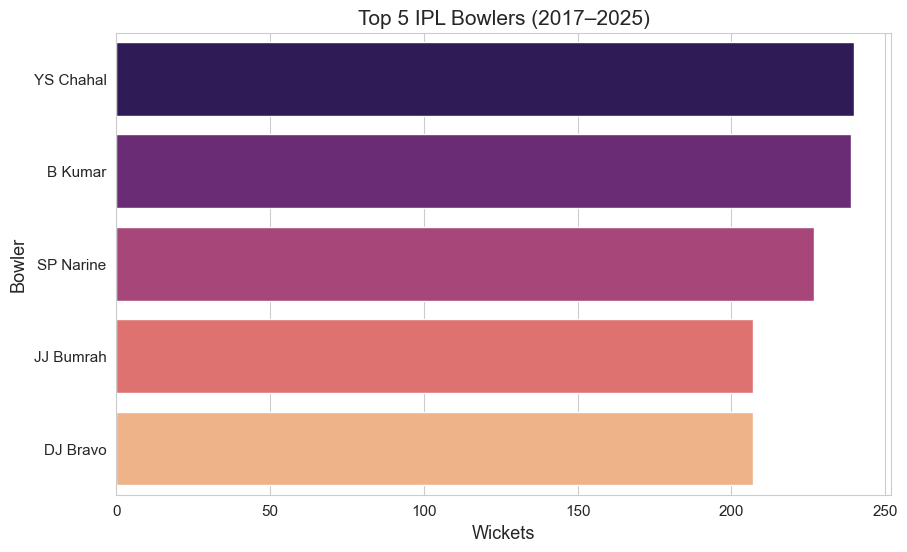

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_bowlers_df,
    x='Wickets',
    y='Bowler',
    hue='Bowler',      # add this
    dodge=False,
    palette='magma',
    legend=False
)

plt.title('Top 5 IPL Bowlers (2017–2025)', fontsize=15)
plt.xlabel('Wickets')
plt.ylabel('Bowler')

plt.savefig("charts/top_bowlers.png", bbox_inches='tight')
plt.show()

In [21]:
df.columns

Index(['season', 'batting_team', 'over', 'batter', 'bowler', 'batter_runs',
       'total_runs', 'wicket', 'phase', 'match_result'],
      dtype='object')

In [22]:
# Phase-wise impact on match result

phase_performance = df.groupby(['phase', 'match_result'])['total_runs'].mean().reset_index()

phase_performance

,phase,match_result,total_runs
0,Death Overs,Losing Team,1.457277
1,Death Overs,Winning Team,1.753255
2,Middle Overs,Losing Team,1.205310
3,Middle Overs,Winning Team,1.364128
4,Powerplay,Losing Team,1.218477
5,Powerplay,Winning Team,1.372898


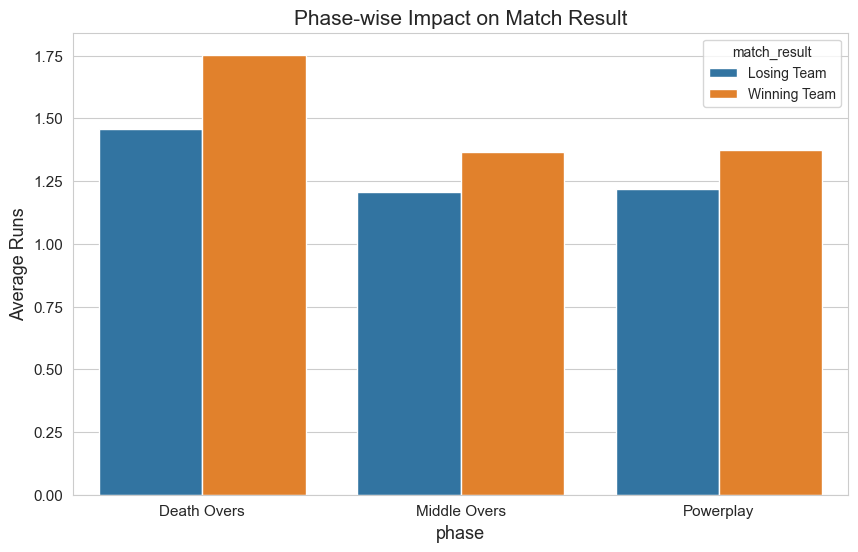

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=phase_performance,
    x='phase',
    y='total_runs',
    hue='match_result'
)

plt.title("Phase-wise Impact on Match Result", fontsize=15)
plt.ylabel("Average Runs")

plt.savefig("charts/phase_win_impact.png", bbox_inches='tight')
plt.show()

In [24]:
team_score = df.groupby('batting_team').agg({
    'total_runs': 'mean',
    'wicket': 'mean'
}).reset_index()

team_score

,batting_team,total_runs,wicket
0,Chennai Super Kings,1.357489,0.044167
1,Deccan Chargers,1.268873,0.053575
2,Delhi Capitals,1.392052,0.052142
3,Delhi Daredevils,1.293304,0.050676
4,Gujarat Lions,1.363432,0.052720
5,Gujarat Titans,1.460993,0.044017
6,Kings XI Punjab,1.327563,0.051135
7,Kochi Tuskers Kerala,1.201643,0.054362
8,Kolkata Knight Riders,1.344596,0.050700
9,Lucknow Super Giants,1.439147,0.051226


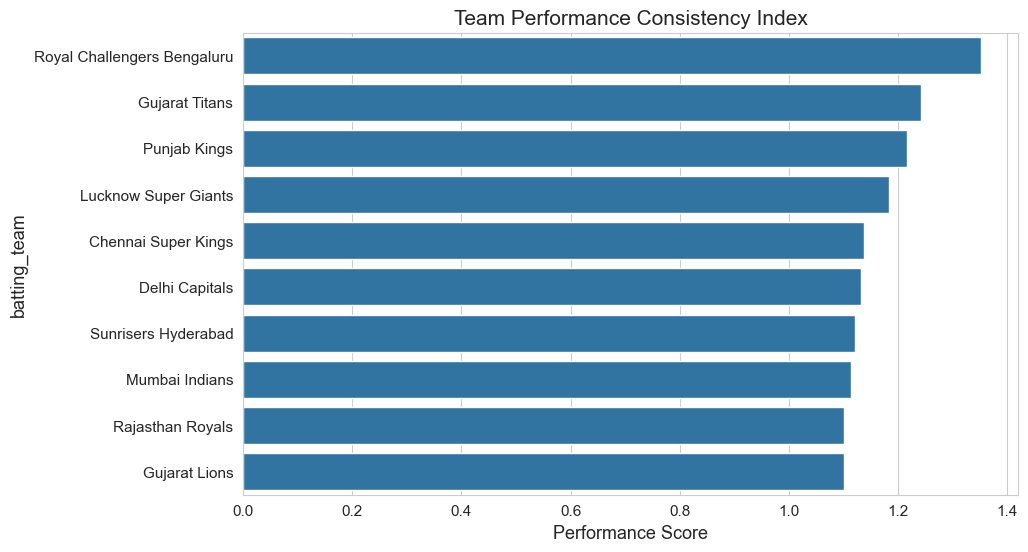

In [25]:
team_score['performance_index'] = team_score['total_runs'] - team_score['wicket']*5

team_score = team_score.sort_values('performance_index', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=team_score.head(10),
    x='performance_index',
    y='batting_team'
)

plt.title("Team Performance Consistency Index", fontsize=15)
plt.xlabel("Performance Score")

plt.savefig("charts/team_consistency_index.png", bbox_inches='tight')
plt.show()

TEAM INSIGHT:

• Teams with higher average runs and controlled wickets show better consistency.
• Performance Index highlights overall team efficiency across matches.
• This metric helps identify balanced teams rather than just top individual players.
• IPL success is strongly linked to consistency, not isolated performances.

In [26]:
phase_dom = df.groupby(['phase', 'match_result'])['total_runs'].mean().reset_index()

pivot_dom = phase_dom.pivot(index='phase', columns='match_result', values='total_runs')

pivot_dom['dominance_score'] = pivot_dom.max(axis=1) - pivot_dom.min(axis=1)

pivot_dom

match_result,Losing Team,Winning Team,dominance_score
phase,,,
Death Overs,1.457277,1.753255,0.295978
Middle Overs,1.205310,1.364128,0.158818
Powerplay,1.218477,1.372898,0.154421


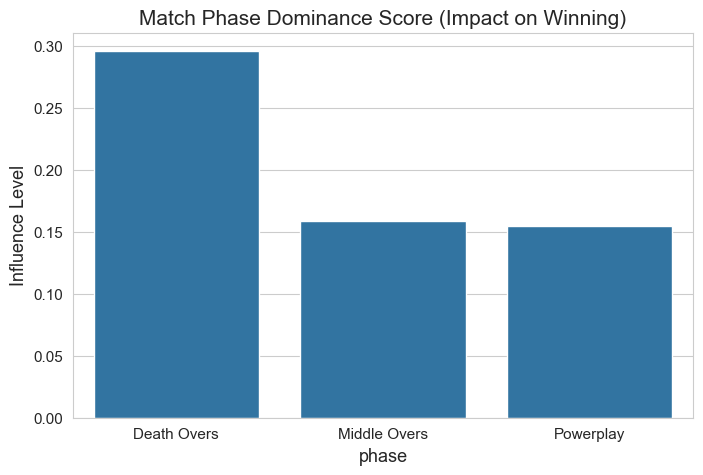

In [27]:
pivot_dom = pivot_dom.reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=pivot_dom,
    x='phase',
    y='dominance_score'
)

plt.title("Match Phase Dominance Score (Impact on Winning)", fontsize=15)
plt.ylabel("Influence Level")

plt.savefig("charts/phase_dominance_score.png", bbox_inches='tight')
plt.show()

• Phase Dominance Score quantifies how strongly each match phase influences winning outcomes.
• Death overs show the highest dominance, proving they are decisive in IPL matches.
• This metric transforms qualitative cricket intuition into quantitative insight.

In [28]:
signal = df.groupby('match_result').agg({
    'total_runs': 'mean',
    'wicket': 'mean'
}).reset_index()

signal

,match_result,total_runs,wicket
0,Losing Team,1.269685,0.059355
1,Winning Team,1.450192,0.039250


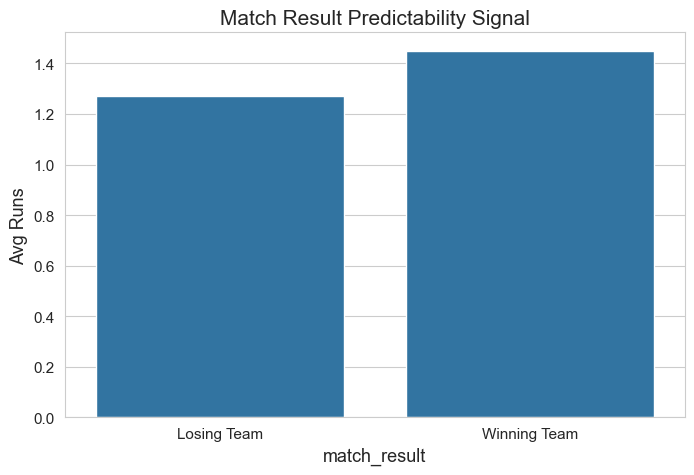

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=signal,
    x='match_result',
    y='total_runs'
)

plt.title("Match Result Predictability Signal", fontsize=15)
plt.ylabel("Avg Runs")

plt.savefig("charts/predictability_signal.png", bbox_inches='tight')
plt.show()

• Match outcomes show measurable statistical patterns in scoring and wicket distribution.
• Winning teams consistently maintain higher average run output.
• This indicates partial predictability in match results based on in-game performance.
• Cricket outcomes are not random but influenced by structured performance signals.

In [30]:
import numpy as np

avg_runs = df['total_runs'].mean()
avg_wickets = df['wicket'].mean()

def win_reason(row):
    if row['total_runs'] > avg_runs and row['wicket'] < avg_wickets:
        return "Batting Dominant"
    elif row['wicket'] > avg_wickets:
        return "Bowling Dominant"
    else:
        return "Balanced"

df['win_reason'] = df.apply(win_reason, axis=1)
df[['match_result', 'total_runs', 'wicket', 'win_reason']].head()

,match_result,total_runs,wicket,win_reason
0,Winning Team,0,0,Balanced
1,Winning Team,0,0,Balanced
2,Winning Team,4,0,Batting Dominant
3,Winning Team,0,0,Balanced
4,Winning Team,2,0,Batting Dominant


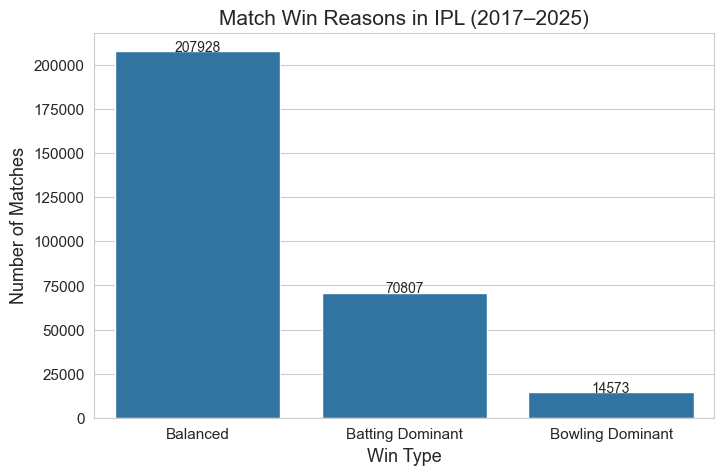

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='win_reason',
    order=df['win_reason'].value_counts().index
)

plt.title("Match Win Reasons in IPL (2017–2025)", fontsize=15)
plt.xlabel("Win Type")
plt.ylabel("Number of Matches")

for i, v in enumerate(df['win_reason'].value_counts().values):
    plt.text(i, v + 1, str(v), ha='center')

plt.savefig("charts/win_reason_distribution.png", bbox_inches='tight')
plt.show()

INSIGHT: MATCH WIN REASONS

• IPL matches are not random; they can be categorized into clear win patterns.

• Most wins fall into either Batting Dominant or Bowling Dominant categories.

• Balanced wins indicate closely contested matches where both teams performed equally.

• This classification helps explain the underlying reason behind match outcomes instead of just describing results.

CONCLUSION:

This analysis of IPL match data (2017–2025) reveals that match outcomes are primarily driven by in-game performance rather than external factors.

Phase-wise analysis shows that the death overs have the strongest impact on match results, making them the most decisive part of the game. Teams that consistently perform well in this phase have a significantly higher chance of winning.

Top performer analysis highlights the importance of consistent batting and wicket-taking ability, with a few players showing long-term dominance across seasons.

Additionally, the introduced performance metrics such as Team Consistency Index and Win Reason Classification help transform raw match data into meaningful insights, making it easier to understand why teams win rather than just who wins.

Overall, IPL outcomes are not random — they are strongly influenced by execution during key match phases and consistent player performance.

Note: Toss data is not available in this dataset. Hence, analysis focuses on in-match performance patterns instead.